In [ ]:
import os
import shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
from tqdm import tqdm
from google.colab import drive, files

# 1. Mount Google Drive
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/Plant_Project'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 2. Kaggle Credentials (using your token string)
os.environ['KAGGLE_KEY'] = "KGAT_bf4ba5bbabd67acd20b4042528889897"
os.environ['KAGGLE_USERNAME'] = "moorix101"

# 3. Download & Unzip Dataset
!pip install -q kaggle
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -q plantvillage-dataset.zip -d plant_data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.03G/2.04G [00:28<00:00, 185MB/s]
100% 2.04G/2.04G [00:28<00:00, 76.0MB/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = 'plant_data/plantvillage dataset/color'
filtered_dir = 'filtered_data'
focus_plants = ['Tomato', 'Apple']

# Create filtered directory
if not os.path.exists(filtered_dir):
    os.makedirs(filtered_dir)

# Copy relevant plant folders
categories = os.listdir(data_dir)
for category in categories:
    if any(plant in category for plant in focus_plants):
        src = os.path.join(data_dir, category)
        dst = os.path.join(filtered_dir, category)
        if not os.path.exists(dst):
            shutil.copytree(src, dst)

# Prepare Data Generators (Rescale 0-255 to 0-1)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    filtered_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training'
)

val_gen = datagen.flow_from_directory(
    filtered_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation'
)

Found 17069 images belonging to 14 classes.
Found 4262 images belonging to 14 classes.


In [ ]:
from skimage.feature import local_binary_pattern
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def extract_lbp_features(generator):
    features, labels = [], []
    radius, n_points = 3, 24 # LBP Parameters
    for i in tqdm(range(len(generator))):
        imgs, lbls = generator[i]
        for img, lbl in zip(imgs, lbls):
            # Convert to grayscale for LBP
            gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
            lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
            (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
            hist = hist.astype("float")
            hist /= (hist.sum() + 1e-7) # Normalization
            features.append(hist)
            labels.append(np.argmax(lbl))
    return np.array(features), np.array(labels)

# Extract and Train SVM
print("\nExtracting Features for SVM...")
X_train_svm, y_train_svm = extract_lbp_features(train_gen)
X_val_svm, y_val_svm = extract_lbp_features(val_gen)

print("Training SVM (RBF Kernel)...")
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train_svm, y_train_svm)

# Save SVM Model
joblib.dump(svm_model, f'{save_path}/svm_leaf_model.pkl')
print(f"✅ SVM Accuracy: {accuracy_score(y_val_svm, svm_model.predict(X_val_svm)) * 100:.2f}%")


Extracting Features for SVM...


100%|██████████| 134/134 [02:26<00:00,  1.09s/it]


Training SVM (RBF Kernel)...
✅ SVM Accuracy: 34.77%


In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers

# Build CNN with Transfer Learning
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                                               include_top=False, weights='imagenet')
base_model.trainable = False

cnn_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(train_gen.class_indices), activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train for 5 Epochs
print("\nTraining CNN (5 Epochs)...")
history = cnn_model.fit(
    train_gen,
    epochs=5,
    validation_data=val_gen
)

# Save CNN Model & History
cnn_model.save(f'{save_path}/cnn_leaf_model.h5')
with open(f'{save_path}/cnn_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print(f"\n✅ CNN Training Complete. Final Val Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Training CNN (5 Epochs)...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


534/534 ━━━━━━━━━━━━━━━━━━━━ 94s 137ms/step - accuracy: 0.6563 - loss: 1.1103 - val_accuracy: 0.8789 - val_loss: 0.3893
Epoch 2/5
534/534 ━━━━━━━━━━━━━━━━━━━━ 40s 75ms/step - accuracy: 0.8795 - loss: 0.3854 - val_accuracy: 0.8989 - val_loss: 0.3016
Epoch 3/5
534/534 ━━━━━━━━━━━━━━━━━━━━ 37s 69ms/step - accuracy: 0.9014 - loss: 0.3022 - val_accuracy: 0.9003 - val_loss: 0.2810
Epoch 4/5
534/534 ━━━━━━━━━━━━━━━━━━━━ 38s 71ms/step - accuracy: 0.9208 - loss: 0.2501 - val_accuracy: 0.9176 - val_loss: 0.2473
Epoch 5/5
534/534 ━━━━━━━━━━━━━━━━━━━━ 43s 81ms/step - accuracy: 0.9230 - loss: 0.2414 - val_accuracy: 0.9148 - val_loss: 0.2479



✅ CNN Training Complete. Final Val Accuracy: 91.48%


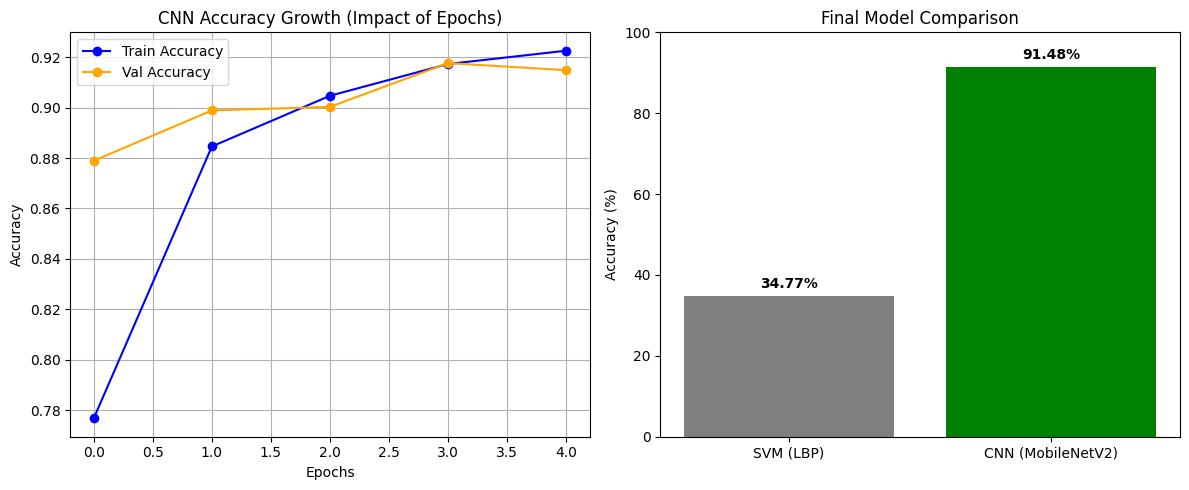

In [ ]:
import matplotlib.pyplot as plt

# 1. Plot CNN Accuracy vs Validation Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', marker='o')
plt.title('CNN Accuracy Growth (Impact of Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. Comparison: SVM vs CNN
plt.subplot(1, 2, 2)
models = ['SVM (LBP)', 'CNN (MobileNetV2)']
# Replace 35.42 with your actual final SVM accuracy result
accuracies = [accuracy_score(y_val_svm, svm_model.predict(X_val_svm)) * 100,
              history.history['val_accuracy'][-1] * 100]

plt.bar(models, accuracies, color=['gray', 'green'])
plt.title('Final Model Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{save_path}/performance_comparison.png')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_path = '/content/drive/MyDrive/Plant_Project'
if not os.path.exists(save_path):
    os.makedirs(save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Save the entire model (architecture + weights)
cnn_model.save(f'{save_path}/cnn_leaf_model.h5')
print("CNN Model saved to Google Drive!")

CNN Model saved to Google Drive!


In [ ]:
import joblib
joblib.dump(svm_model, f'{save_path}/svm_leaf_model.pkl')
print("SVM Model saved to Google Drive!")

SVM Model saved to Google Drive!


In [ ]:
# ── FINAL CELL: Serve the CNN model as an API (Corrigée pour chargement Drive) ──
!pip install -q flask flask-cors pyngrok

from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
import numpy as np
import tensorflow as tf
from PIL import Image
import io, os
from google.colab import drive

# 1. Montage du Drive si nécessaire
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

app = Flask(__name__)
CORS(app)

# 2. Chemin vers ton modèle sauvegardé sur Google Drive
save_path = '/content/drive/MyDrive/Plant_Project'
model_file = f'{save_path}/cnn_leaf_model.h5'

if os.path.exists(model_file):
    print("✅ Chargement du modèle depuis le Drive...")
    model = tf.keras.models.load_model(model_file)
else:
    print("❌ Erreur : Modèle introuvable. Vérifie le chemin sur ton Drive.")

# 3. Liste manuelle des classes (pour éviter de dépendre de train_gen)
# Assure-toi que l'ordre correspond à celui de ton entraînement !
idx_to_class = {
    0: "Apple___Apple_scab", 1: "Apple___Black_rot", 2: "Apple___Cedar_apple_rust", 3: "Apple___healthy",
    4: "Tomato___Bacterial_spot", 5: "Tomato___Early_blight", 6: "Tomato___Late_blight", 7: "Tomato___Leaf_Mold",
    8: "Tomato___Septoria_leaf_spot", 9: "Tomato___Spider_mites", 10: "Tomato___Target_Spot",
    11: "Tomato___TYLCV", 12: "Tomato___Tomato_mosaic_virus", 13: "Tomato___healthy"
}

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return jsonify({'error': 'No file uploaded'}), 400

    file  = request.files['file']
    # Prétraitement identique à l'entraînement [cite: 36, 81]
    img   = Image.open(io.BytesIO(file.read())).convert('RGB').resize((224, 224))
    arr   = np.array(img) / 255.0
    batch = np.expand_dims(arr, 0)

    probs = model.predict(batch, verbose=0)[0]

    predictions = sorted(
        [{"label": idx_to_class[i], "confidence": float(p)} for i, p in enumerate(probs)],
        key=lambda x: x["confidence"], reverse=True
    )
    return jsonify({"predictions": predictions})

# 4. Configuration ngrok
ngrok.set_auth_token("2t1uLHr40FygOesCsi2hgvAzTGL_84yuNuodxAuApWSKWf24C")

# Fermer les tunnels existants pour éviter les erreurs
ngrok.kill()

# Démarrage du tunnel
public_url = ngrok.connect(5000).public_url
print(f"\n✅ Ton interface est prête !")
print(f"🔗 Copie cette URL dans ton site web : {public_url}\n")

app.run(port=5000)

✅ Chargement du modèle depuis le Drive...



✅ Ton interface est prête !
🔗 Copie cette URL dans ton site web : https://ee91-8-228-68-72.ngrok-free.app

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [10/Mar/2026 11:45:43] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [10/Mar/2026 11:46:10] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [10/Mar/2026 12:12:59] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [10/Mar/2026 12:13:17] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [10/Mar/2026 12:13:24] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [10/Mar/2026 12:21:16] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [10/Mar/2026 13:04:39] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [10/Mar/2026 14:12:21] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [10/Mar/2026 14:12:56] "POST /predict HTTP/1.1" 200 -
